# Assignment 2 – Pokemon Image Classification (Machine Learning)

**Course:** Programming for Artificial Intelligence and Data Science (CO3135)  
**Dataset:** Pokemon Image Dataset — 898 Pokémon classes, 2 503 images  
**Task:** Multi-class image classification

---

## Approach Overview

This notebook applies machine learning to the same Pokémon image dataset explored in Assignment 1. Two complementary approaches are implemented and compared:

| # | Approach | Method |
|---|----------|--------|
| A | **Feature Extraction + Classical ML** | Freeze pretrained EfficientNet-B0, extract 1 280-dim embeddings, train SVM / Logistic Regression / k-NN |
| B | **Transfer Learning (Fine-tuning)** | Replace EfficientNet-B0 classifier head, train head with frozen backbone, then unfreeze top blocks |

### EDA Insights Applied
From Assignment 1 EDA, the key design decisions are:

- **Extreme long-tail distribution** (898 classes, avg 2.79 images/class) → filter to classes with ≥ 3 images to enable a meaningful train/val/test split.
- **All images are JPEG / RGB**, consistent resolution → uniform preprocessing is safe.
- **One cross-class duplicate** (Appletun ↔ Flapple) → deduplicated before splitting.
- **Aspect-ratio outliers** → square-resize to 224 × 224 with padding to avoid distortion.
- **Split coverage risk** (659 classes had no validation sample in random split) → use stratified splitting to guarantee every class appears in every split where possible.

In [1]:
# ── Install required packages (run once) ──────────────────────────────────────
import subprocess, sys

_packages = {
    "torch":    ["torch", "torchvision", "--index-url",
                 "https://download.pytorch.org/whl/cpu"],
    "tqdm":     ["tqdm"],
    "seaborn":  ["seaborn"],
}

for pkg, args in _packages.items():
    try:
        __import__(pkg)
        print(f"  ✓ {pkg}")
    except ImportError:
        print(f"  Installing {pkg} …")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + args)
        print(f"  ✓ {pkg} installed")

print("\nAll packages ready.")

  Installing torch …
  ✓ torch installed
  ✓ tqdm
  ✓ seaborn

All packages ready.


In [4]:
# ── Imports and global configuration ─────────────────────────────────────────
import warnings, random, hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
import torchvision.models as tv_models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    top_k_accuracy_score, confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_PATH = Path("../../datasets/pokemon/data/images")

# ── Hyperparameters ───────────────────────────────────────────────────────────
MIN_IMAGES_PER_CLASS = 3     # EDA insight: need ≥3 for a train/val/test split
IMG_SIZE             = 224   # EfficientNet-B0 native input size
BATCH_SIZE           = 32
DEVICE               = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Styling ───────────────────────────────────────────────────────────────────
COLORS = {
    "primary":   "#2563EB",
    "secondary": "#0EA5E9",
    "accent":    "#14B8A6",
    "warning":   "#F59E0B",
    "danger":    "#EF4444",
    "neutral":   "#334155",
}
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)


def style_ax(ax, title, xlabel=None, ylabel=None):
    ax.set_title(title, loc="left", fontsize=12, fontweight="bold",
                 color=COLORS["neutral"], pad=8)
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.set_facecolor("#F8FAFC")
    ax.grid(axis="y", alpha=0.25)
    sns.despine(ax=ax)


print(f"Device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")


Device: cpu
PyTorch version: 2.11.0+cpu


## 1. EDA-Informed Data Loading & Preprocessing

### Design Decisions from Assignment 1 EDA

| EDA Finding | ML Decision |
|---|---|
| 898 classes, avg 2.79 img/class (long-tail) | Filter to ≥ 3 images/class for valid splits |
| 1 cross-class duplicate hash (Appletun ↔ Flapple) | Remove duplicate files before splitting |
| All JPEG / RGB, no corrupted files | No format conversion needed |
| Aspect-ratio outliers present | Resize to 224×224 with `transforms.Resize` |
| File-size and megapixel distributions have outliers | Normalize pixel values with ImageNet stats |

In [5]:
# ── 1.1 Index all image files ─────────────────────────────────────────────────
image_paths = sorted([p for p in DATA_PATH.rglob("*") if p.is_file()])

records = []
for p in image_paths:
    records.append({
        "class_name": p.parent.name,
        "file_path":  str(p),
        "ext":        p.suffix.lower(),
    })

raw_df = pd.DataFrame(records)

print(f"Total images indexed : {len(raw_df):,}")
print(f"Total classes found  : {raw_df['class_name'].nunique():,}")
display(raw_df.head())

Total images indexed : 2,503
Total classes found  : 898


,class_name,file_path,ext
0,Abomasnow,..\..\datasets\pokemon\data\images\Abomasnow\0...,.jpg
1,Abomasnow,..\..\datasets\pokemon\data\images\Abomasnow\1...,.jpg
2,Abomasnow,..\..\datasets\pokemon\data\images\Abomasnow\2...,.jpg
3,Abomasnow,..\..\datasets\pokemon\data\images\Abomasnow\3...,.jpg
4,Abra,..\..\datasets\pokemon\data\images\Abra\0.jpg,.jpg


In [6]:
# ── 1.2 Remove exact-duplicate files (EDA: 1 cross-class duplicate group) ────
def file_md5(path_str: str, chunk: int = 8192) -> str:
    h = hashlib.md5()
    with open(path_str, "rb") as f:
        while blk := f.read(chunk):
            h.update(blk)
    return h.hexdigest()

print("Computing MD5 hashes to detect duplicates …")
hashes = [file_md5(fp) for fp in tqdm(raw_df["file_path"], desc="MD5")]
raw_df["md5"] = hashes

# Keep one file per md5 (drop extra duplicates)
before = len(raw_df)
raw_df = raw_df.drop_duplicates(subset="md5", keep="first").reset_index(drop=True)
after  = len(raw_df)

print(f"\nRemoved {before - after:,} exact-duplicate files  ({before} → {after})")

Computing MD5 hashes to detect duplicates …


MD5:   0%|          | 0/2503 [00:00<?, ?it/s]


Removed 1 exact-duplicate files  (2503 → 2502)


Min images per class : 3
Classes kept         : 378  (dropped 520)
Images after filter  : 1,517

Images/class  →  min=3  median=4  mean=4.0  max=8


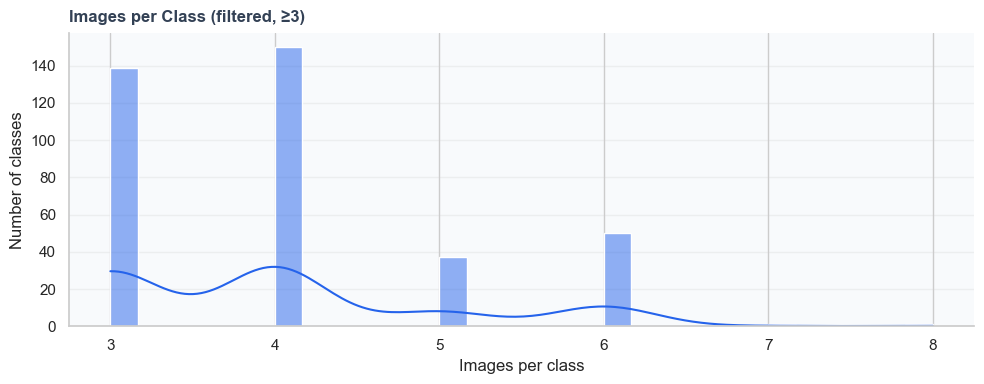

In [7]:
# ── 1.3 Filter: keep only classes with ≥ MIN_IMAGES_PER_CLASS images ─────────
#
# Rationale (EDA): 520 of 898 classes have ≤ 2 images, making a 3-way split
# impossible. We filter to ≥ 3 images so every class can contribute at least
# one sample to each of train / val / test.
#
class_counts = raw_df["class_name"].value_counts()
valid_classes = class_counts[class_counts >= MIN_IMAGES_PER_CLASS].index

df = raw_df[raw_df["class_name"].isin(valid_classes)].reset_index(drop=True)

kept_classes   = df["class_name"].nunique()
dropped_classes = raw_df["class_name"].nunique() - kept_classes

print(f"Min images per class : {MIN_IMAGES_PER_CLASS}")
print(f"Classes kept         : {kept_classes:,}  (dropped {dropped_classes:,})")
print(f"Images after filter  : {len(df):,}")

# Quick distribution of images per class after filtering
per_class = df["class_name"].value_counts()
print(f"\nImages/class  →  min={per_class.min()}  median={int(per_class.median())}  "
      f"mean={per_class.mean():.1f}  max={per_class.max()}")

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(per_class, bins=30, kde=True, ax=ax, color=COLORS["primary"])
style_ax(ax, f"Images per Class (filtered, ≥{MIN_IMAGES_PER_CLASS})",
         "Images per class", "Number of classes")
plt.tight_layout()
plt.show()

## 2. Train / Validation / Test Split

A **stratified per-class split** (70 % train · 15 % val · 15 % test) is applied so that every class is represented in all three partitions. This directly addresses the "split coverage risk" finding from the EDA, where a purely random split left 659 classes with no validation sample.

In [8]:
# ── 2.1 Stratified per-class split ───────────────────────────────────────────
def per_class_split(group: pd.DataFrame,
                    train_ratio: float = 0.70,
                    val_ratio:   float = 0.15) -> pd.Series:
    """Assign each image in a class group to train / val / test."""
    idx = group.index.tolist()
    random.shuffle(idx)
    n = len(idx)

    if n == 3:
        # Minimum viable case: 1 per split
        return pd.Series(["train", "val", "test"], index=idx)

    n_train = max(1, int(round(n * train_ratio)))
    n_val   = max(1, int(round(n * val_ratio)))
    n_test  = n - n_train - n_val
    if n_test < 1:          # edge case: ensure at least 1 test sample
        n_test  = 1
        n_train = n - n_val - n_test

    splits = ["train"] * n_train + ["val"] * n_val + ["test"] * n_test
    return pd.Series(splits, index=idx)


split_col  = df.groupby("class_name", group_keys=False).apply(per_class_split)
df["split"] = split_col.reindex(df.index)

# ── 2.2 Encode labels ─────────────────────────────────────────────────────────
le = LabelEncoder()
df["label"] = le.fit_transform(df["class_name"])
NUM_CLASSES = len(le.classes_)

# ── 2.3 Coverage report ───────────────────────────────────────────────────────
split_counts = df["split"].value_counts().rename_axis("split").reset_index(name="count")
split_counts["pct"] = (split_counts["count"] / len(df) * 100).round(1)

print(f"Number of classes : {NUM_CLASSES}")
print(f"\nSplit distribution:")
display(split_counts)

coverage = (
    df.pivot_table(index="class_name", columns="split",
                   values="file_path", aggfunc="size", fill_value=0)
    .reset_index()
)
for col in ["train", "val", "test"]:
    if col not in coverage.columns:
        coverage[col] = 0

missing_val  = int((coverage["val"]   == 0).sum())
missing_test = int((coverage["test"]  == 0).sum())
tiny_train   = int((coverage["train"] <= 1).sum())

print(f"\nClasses missing val  : {missing_val}")
print(f"Classes missing test : {missing_test}")
print(f"Classes with ≤1 train sample : {tiny_train}")

Number of classes : 378

Split distribution:


,split,count,pct
0,train,761,50.2
1,test,378,24.9
2,val,378,24.9



Classes missing val  : 0
Classes missing test : 0
Classes with ≤1 train sample : 139


## 3. Approach A — Feature Extraction + Classical ML

### Rationale
Given that most classes have only 3–5 images (extreme few-shot setting), end-to-end fine-tuning is data-hungry and risky. A strong baseline is to **freeze the pretrained backbone** (EfficientNet-B0, ImageNet-pretrained) and treat its penultimate-layer output as a fixed 1 280-dimensional feature vector. Classical ML classifiers can then be trained on these rich embeddings with very few examples per class.

### Pipeline
```
Image → Resize 224×224 → Normalize (ImageNet μ/σ)
      → EfficientNet-B0 [frozen] → 1280-dim feature
      → StandardScaler
      → Classifier (SVM / LogReg / k-NN)
```

In [9]:
# ── 3.1 Build the feature extractor ──────────────────────────────────────────
#
# EfficientNet-B0 pretrained on ImageNet-1k.
# We strip the final classifier head (model.classifier) and use the
# adaptive-average-pooled feature map (shape: [B, 1280, 1, 1] → [B, 1280]).
#
_base = tv_models.efficientnet_b0(
    weights=tv_models.EfficientNet_B0_Weights.IMAGENET1K_V1
)
_base.eval()

class FeatureExtractor(nn.Module):
    """EfficientNet-B0 without the classification head."""
    def __init__(self, base_model):
        super().__init__()
        self.features = base_model.features   # CNN blocks
        self.avgpool  = base_model.avgpool     # AdaptiveAvgPool2d → (1,1)

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        return x.flatten(1)                   # → (batch, 1280)

feature_extractor = FeatureExtractor(_base).to(DEVICE)
feature_extractor.eval()

# Freeze all parameters – no gradient computation needed
for p in feature_extractor.parameters():
    p.requires_grad = False

print("Feature extractor: EfficientNet-B0 (frozen)")
print(f"Output feature dim: 1280")

# ── Transform: no augmentation for feature extraction ────────────────────────
extract_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std= [0.229, 0.224, 0.225]),
])

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\datth/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:01<00:00, 11.1MB/s]

Feature extractor: EfficientNet-B0 (frozen)
Output feature dim: 1280


In [10]:
# ── 3.2 Custom Dataset and DataLoader ────────────────────────────────────────
class PokemonDataset(Dataset):
    """Loads images from file paths and applies a transform."""
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = list(file_paths)
        self.labels     = list(labels)
        self.transform  = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img = Image.open(self.file_paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


def make_loader(split_name: str, transform, shuffle: bool = False) -> DataLoader:
    subset = df[df["split"] == split_name]
    ds = PokemonDataset(subset["file_path"].values,
                        subset["label"].values,
                        transform)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=0, pin_memory=False)


# ── 3.3 Extract features for all splits ──────────────────────────────────────
@torch.no_grad()
def extract_features(loader: DataLoader) -> tuple[np.ndarray, np.ndarray]:
    all_feats, all_labels = [], []
    for imgs, labels in tqdm(loader, desc="Extracting", leave=False):
        imgs = imgs.to(DEVICE)
        feats = feature_extractor(imgs).cpu().numpy()
        all_feats.append(feats)
        all_labels.append(labels.numpy())
    return np.vstack(all_feats), np.concatenate(all_labels)


print("Extracting features …")
X_train, y_train = extract_features(make_loader("train", extract_transform))
X_val,   y_val   = extract_features(make_loader("val",   extract_transform))
X_test,  y_test  = extract_features(make_loader("test",  extract_transform))

print(f"\nFeature shapes:")
print(f"  Train : {X_train.shape}  labels: {y_train.shape}")
print(f"  Val   : {X_val.shape}  labels: {y_val.shape}")
print(f"  Test  : {X_test.shape}  labels: {y_test.shape}")

Extracting features …


Extracting:   0%|          | 0/24 [00:00<?, ?it/s]

Extracting:   0%|          | 0/12 [00:00<?, ?it/s]

Extracting:   0%|          | 0/12 [00:00<?, ?it/s]


Feature shapes:
  Train : (761, 1280)  labels: (761,)
  Val   : (378, 1280)  labels: (378,)
  Test  : (378, 1280)  labels: (378,)


In [11]:
# ── 3.4 Scale features (StandardScaler fitted on train only) ─────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print("Features standardized (zero mean, unit variance).")
print(f"Train feature mean ≈ {X_train_s.mean():.4f}  std ≈ {X_train_s.std():.4f}")

Features standardized (zero mean, unit variance).
Train feature mean ≈ 0.0000  std ≈ 1.0000


In [13]:
# ── 3.5 Train and evaluate Classical ML classifiers ──────────────────────────
#
# Three classifiers are compared on the same scaled EfficientNet features:
#   • SVM (RBF kernel) – strong on high-dimensional embeddings
#   • Logistic Regression (multinomial, L-BFGS) – fast linear baseline
#   • k-Nearest Neighbors (k=5) – non-parametric, no training needed
#
classifiers = {
    "SVM (RBF)": SVC(
        kernel="rbf", C=10, gamma="scale",
        probability=True, random_state=SEED, max_iter=2000
    ),
    "Logistic Regression": LogisticRegression(
        solver="lbfgs",
        C=1.0, max_iter=1000, random_state=SEED
    ),
    "k-NN (k=5)": KNeighborsClassifier(
        n_neighbors=5, metric="cosine"
    ),
}

classical_results = {}

for name, clf in classifiers.items():
    print(f"\nTraining {name} …")
    clf.fit(X_train_s, y_train)

    # Evaluate on val and test
    val_preds  = clf.predict(X_val_s)
    test_preds = clf.predict(X_test_s)

    val_acc  = accuracy_score(y_val,  val_preds)
    test_acc = accuracy_score(y_test, test_preds)

    # Top-5 accuracy (requires predict_proba)
    if hasattr(clf, "predict_proba"):
        val_proba  = clf.predict_proba(X_val_s)
        test_proba = clf.predict_proba(X_test_s)
        val_top5   = top_k_accuracy_score(y_val,  val_proba,  k=5,
                                          labels=np.arange(NUM_CLASSES))
        test_top5  = top_k_accuracy_score(y_test, test_proba, k=5,
                                          labels=np.arange(NUM_CLASSES))
    else:
        val_top5 = test_top5 = float("nan")

    classical_results[name] = {
        "val_acc":   val_acc,
        "test_acc":  test_acc,
        "val_top5":  val_top5,
        "test_top5": test_top5,
    }

    print(f"  Val  — Top-1: {val_acc:.4f}  Top-5: {val_top5:.4f}")
    print(f"  Test — Top-1: {test_acc:.4f}  Top-5: {test_top5:.4f}")



Training SVM (RBF) …
  Val  — Top-1: 0.3175  Top-5: 0.0767
  Test — Top-1: 0.3333  Top-5: 0.0899

Training Logistic Regression …
  Val  — Top-1: 0.6323  Top-5: 0.8254
  Test — Top-1: 0.6455  Top-5: 0.8439

Training k-NN (k=5) …
  Val  — Top-1: 0.3254  Top-5: 0.7646
  Test — Top-1: 0.3413  Top-5: 0.7989


Classical ML Results (EfficientNet-B0 features):


,Classifier,Val Top-1,Test Top-1,Val Top-5,Test Top-5
0,SVM (RBF),0.3175,0.3333,0.0767,0.0899
1,Logistic Regression,0.6323,0.6455,0.8254,0.8439
2,k-NN (k=5),0.3254,0.3413,0.7646,0.7989


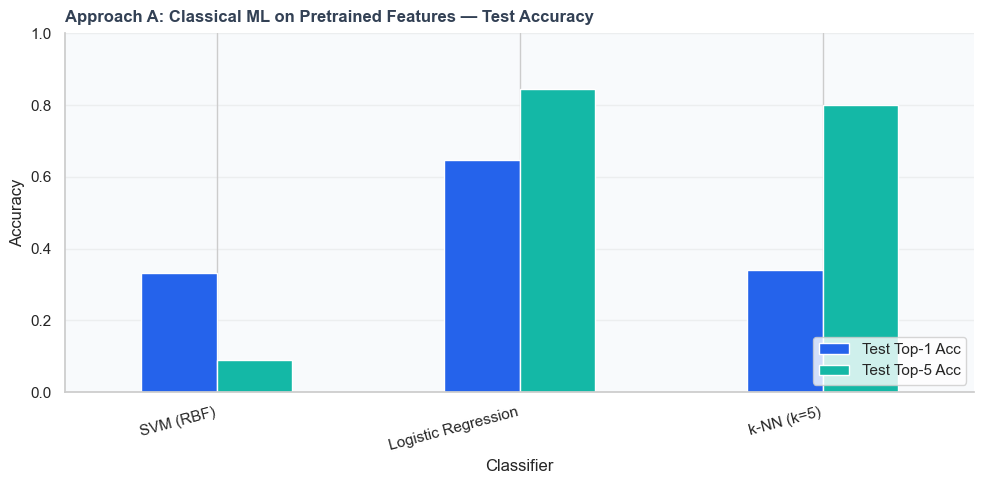

In [14]:
# ── 3.6 Classical ML results table ───────────────────────────────────────────
clf_df = pd.DataFrame(classical_results).T.reset_index().rename(columns={"index": "Classifier"})

def _fmt(x):
    if isinstance(x, float) and not np.isnan(x):
        return f"{x:.4f}"
    return "N/A"

for col in ["val_acc", "test_acc", "val_top5", "test_top5"]:
    clf_df[col] = clf_df[col].map(_fmt)

clf_df.columns = ["Classifier", "Val Top-1", "Test Top-1", "Val Top-5", "Test Top-5"]
print("Classical ML Results (EfficientNet-B0 features):")
display(clf_df)

# ── 3.7 Bar chart comparison ──────────────────────────────────────────────────
metrics_plot = pd.DataFrame(
    {clf: [v["test_acc"], v["test_top5"]]
     for clf, v in classical_results.items()},
    index=["Test Top-1 Acc", "Test Top-5 Acc"],
).T

fig, ax = plt.subplots(figsize=(10, 5))
metrics_plot.plot(kind="bar", ax=ax,
                  color=[COLORS["primary"], COLORS["accent"]],
                  edgecolor="white", width=0.5)
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
style_ax(ax, "Approach A: Classical ML on Pretrained Features — Test Accuracy",
         "Classifier", "Accuracy")
ax.legend(loc="lower right")
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.show()

In [15]:
# ── 3.8 Detailed classification report for the best classical classifier ─────
best_clf_name = max(classical_results, key=lambda k: classical_results[k]["test_acc"])
best_clf      = classifiers[best_clf_name]

print(f"Best classical classifier: {best_clf_name}")
test_preds_best = best_clf.predict(X_test_s)
report_str = classification_report(
    y_test, test_preds_best,
    target_names=[le.classes_[i] for i in sorted(np.unique(y_test))],
    labels=sorted(np.unique(y_test)),
    zero_division=0,
    output_dict=False
)

# Show macro/weighted averages only (full report is too large for 300+ classes)
lines = report_str.split("\n")
summary_lines = [l for l in lines if "accuracy" in l or "macro avg" in l
                 or "weighted avg" in l or l.strip() == ""]
print("\nClassification report summary (test set):")
print("\n".join(summary_lines))

Best classical classifier: Logistic Regression

Classification report summary (test set):


    accuracy                           0.65       378
   macro avg       0.55      0.65      0.58       378
weighted avg       0.55      0.65      0.58       378



## 4. Approach B — Transfer Learning (Fine-tuning EfficientNet-B0)

### Strategy
Transfer learning re-uses the ImageNet pretrained weights and adapts the network to the Pokémon domain in **two phases**:

| Phase | Backbone | Classifier head | LR | Epochs |
|-------|----------|-----------------|-----|--------|
| 1 — Head only | Frozen | Trainable | 1e-3 | 10 |
| 2 — Partial unfreeze | Last 2 feature blocks unfrozen | Trainable | 1e-4 | 5 |

Phase 1 warms up the new head without destroying the pretrained features. Phase 2 then allows the top backbone layers to adapt to Pokémon-specific textures at a lower learning rate.

### Data Augmentation
To combat the very small per-class sample size the training pipeline applies:
- **RandomHorizontalFlip** — Pokémon sprites are symmetric, so flipping is safe
- **RandomRotation (±20°)** — orientation invariance
- **ColorJitter** — brightness/contrast/saturation shifts for robustness
- **RandomAffine** — mild translation/scale variation

In [16]:
# ── 4.1 Data transforms ───────────────────────────────────────────────────────

# Training: augmented (addresses few-shot risk from EDA)
train_transform = T.Compose([
    T.Resize((IMG_SIZE + 16, IMG_SIZE + 16)),   # slight over-size before crop
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(),
    T.RandomRotation(degrees=20),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std= [0.229, 0.224, 0.225]),
])

# Validation / test: deterministic
eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std= [0.229, 0.224, 0.225]),
])

# DataLoaders for fine-tuning (shuffle train to avoid order bias)
ft_train_loader = make_loader("train", train_transform, shuffle=True)
ft_val_loader   = make_loader("val",   eval_transform,  shuffle=False)
ft_test_loader  = make_loader("test",  eval_transform,  shuffle=False)

print(f"Fine-tuning loaders ready.")
print(f"  Train batches : {len(ft_train_loader)}")
print(f"  Val   batches : {len(ft_val_loader)}")
print(f"  Test  batches : {len(ft_test_loader)}")

Fine-tuning loaders ready.
  Train batches : 24
  Val   batches : 12
  Test  batches : 12


In [17]:
# ── 4.2 Model definition ─────────────────────────────────────────────────────

class PokemonFineTuner(nn.Module):
    """
    EfficientNet-B0 with a new classification head for Pokémon classes.

    Architecture:
        EfficientNet-B0 backbone (features + avgpool)  →  Dropout  →  Linear(num_classes)

    The backbone starts fully frozen. Call unfreeze_last_blocks(n) to
    selectively unfreeze the final n feature blocks for Phase 2 fine-tuning.
    """

    def __init__(self, num_classes: int, dropout: float = 0.35):
        super().__init__()
        base = tv_models.efficientnet_b0(
            weights=tv_models.EfficientNet_B0_Weights.IMAGENET1K_V1
        )
        # ── Backbone (initially frozen) ───────────────────────────────────────
        self.features = base.features   # Sequential of MBConv blocks
        self.avgpool  = base.avgpool    # AdaptiveAvgPool2d(1, 1)

        for p in self.parameters():
            p.requires_grad = False

        # ── New head (always trainable) ───────────────────────────────────────
        in_features = base.classifier[1].in_features   # 1280
        self.head = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, num_classes),
        )
        # Head parameters are NOT frozen
        for p in self.head.parameters():
            p.requires_grad = True

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.avgpool(x)
        x = x.flatten(1)
        return self.head(x)

    def unfreeze_last_blocks(self, n: int = 2) -> None:
        """Unfreeze the last n feature blocks of the backbone."""
        blocks = list(self.features.children())
        for block in blocks[-n:]:
            for p in block.parameters():
                p.requires_grad = True
        n_trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"  Unfroze last {n} block(s).  Trainable params: {n_trainable:,}")


model = PokemonFineTuner(num_classes=NUM_CLASSES).to(DEVICE)
total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: EfficientNet-B0 → {NUM_CLASSES} classes")
print(f"Total params     : {total_params:,}")
print(f"Trainable params : {trainable_params:,}  (head only)")

Model: EfficientNet-B0 → 378 classes
Total params     : 4,491,766
Trainable params : 484,218  (head only)


In [18]:
# ── 4.3 Training utilities ────────────────────────────────────────────────────

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device, k=5):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss    = criterion(outputs, labels)

        total_loss += loss.item() * imgs.size(0)
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())
        all_probs.append(torch.softmax(outputs, dim=1).cpu().numpy())

    all_preds  = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    all_probs  = np.concatenate(all_probs)

    top1 = correct / total
    top5 = top_k_accuracy_score(all_labels, all_probs, k=k,
                                labels=np.arange(NUM_CLASSES))
    return total_loss / total, top1, top5, all_preds, all_labels


print("Training utilities defined.")

Training utilities defined.


In [19]:
# ── 4.4 Phase 1: Train head only (backbone frozen) ────────────────────────────
PHASE1_EPOCHS = 10
PHASE1_LR     = 1e-3

criterion  = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer  = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                        lr=PHASE1_LR, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=PHASE1_EPOCHS)

history = {"phase": [], "epoch": [], "train_loss": [], "val_loss": [],
           "train_acc": [], "val_acc": [], "val_top5": []}

print("=" * 60)
print("Phase 1 — Training classification head (backbone frozen)")
print("=" * 60)

best_val_acc   = 0.0
best_state     = None

for epoch in range(1, PHASE1_EPOCHS + 1):
    tr_loss, tr_acc         = train_one_epoch(model, ft_train_loader,
                                              criterion, optimizer, DEVICE)
    vl_loss, vl_acc, vl_t5, _, _ = evaluate(model, ft_val_loader,
                                             criterion, DEVICE)
    scheduler.step()

    history["phase"].append(1)
    history["epoch"].append(epoch)
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)
    history["val_top5"].append(vl_t5)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        best_state   = {k: v.clone() for k, v in model.state_dict().items()}

    print(f"  Ep {epoch:02d}/{PHASE1_EPOCHS} | "
          f"tr_loss={tr_loss:.4f}  tr_acc={tr_acc:.4f} | "
          f"val_loss={vl_loss:.4f}  val_acc={vl_acc:.4f}  val_top5={vl_t5:.4f}")

print(f"\nBest val Top-1 (Phase 1): {best_val_acc:.4f}")

Phase 1 — Training classification head (backbone frozen)
  Ep 01/10 | tr_loss=6.1506  tr_acc=0.0026 | val_loss=5.8467  val_acc=0.0397  val_top5=0.0873
  Ep 02/10 | tr_loss=5.3929  tr_acc=0.0999 | val_loss=5.5635  val_acc=0.0899  val_top5=0.1693
  Ep 03/10 | tr_loss=4.8115  tr_acc=0.2641 | val_loss=5.3051  val_acc=0.1296  val_top5=0.2698
  Ep 04/10 | tr_loss=4.3619  tr_acc=0.4231 | val_loss=5.0929  val_acc=0.1720  val_top5=0.3333
  Ep 05/10 | tr_loss=4.0048  tr_acc=0.5164 | val_loss=4.9141  val_acc=0.2037  val_top5=0.3968
  Ep 06/10 | tr_loss=3.7364  tr_acc=0.5703 | val_loss=4.8085  val_acc=0.2249  val_top5=0.4048
  Ep 07/10 | tr_loss=3.5310  tr_acc=0.6242 | val_loss=4.7286  val_acc=0.2381  val_top5=0.4365
  Ep 08/10 | tr_loss=3.4103  tr_acc=0.6767 | val_loss=4.6908  val_acc=0.2407  val_top5=0.4365
  Ep 09/10 | tr_loss=3.3354  tr_acc=0.7254 | val_loss=4.6781  val_acc=0.2566  val_top5=0.4392
  Ep 10/10 | tr_loss=3.3385  tr_acc=0.6965 | val_loss=4.6583  val_acc=0.2593  val_top5=0.4471

Be

In [20]:
# ── 4.5 Phase 2: Unfreeze last 2 backbone blocks, fine-tune ──────────────────
PHASE2_EPOCHS = 5
PHASE2_LR     = 1e-4

# Restore best Phase-1 weights before unfreezing
model.load_state_dict(best_state)

print("=" * 60)
print("Phase 2 — Partial unfreeze (last 2 backbone blocks)")
print("=" * 60)

model.unfreeze_last_blocks(n=2)

optimizer2 = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                        lr=PHASE2_LR, weight_decay=1e-4)
scheduler2 = optim.lr_scheduler.CosineAnnealingLR(optimizer2, T_max=PHASE2_EPOCHS)

# Track best model across both phases
p2_best_val_acc = best_val_acc

for epoch in range(1, PHASE2_EPOCHS + 1):
    tr_loss, tr_acc         = train_one_epoch(model, ft_train_loader,
                                              criterion, optimizer2, DEVICE)
    vl_loss, vl_acc, vl_t5, _, _ = evaluate(model, ft_val_loader,
                                             criterion, DEVICE)
    scheduler2.step()

    history["phase"].append(2)
    history["epoch"].append(PHASE1_EPOCHS + epoch)
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)
    history["val_top5"].append(vl_t5)

    if vl_acc > p2_best_val_acc:
        p2_best_val_acc = vl_acc
        best_state      = {k: v.clone() for k, v in model.state_dict().items()}

    print(f"  Ep {PHASE1_EPOCHS + epoch:02d}/{PHASE1_EPOCHS + PHASE2_EPOCHS} | "
          f"tr_loss={tr_loss:.4f}  tr_acc={tr_acc:.4f} | "
          f"val_loss={vl_loss:.4f}  val_acc={vl_acc:.4f}  val_top5={vl_t5:.4f}")

# Load the overall best checkpoint
model.load_state_dict(best_state)
print(f"\nBest val Top-1 (all phases): {p2_best_val_acc:.4f}")

Phase 2 — Partial unfreeze (last 2 backbone blocks)
  Unfroze last 2 block(s).  Trainable params: 1,613,610
  Ep 11/15 | tr_loss=3.1816  tr_acc=0.7017 | val_loss=4.5094  val_acc=0.2460  val_top5=0.4074
  Ep 12/15 | tr_loss=2.9924  tr_acc=0.6886 | val_loss=4.4305  val_acc=0.2619  val_top5=0.4286
  Ep 13/15 | tr_loss=2.9033  tr_acc=0.6741 | val_loss=4.3645  val_acc=0.2672  val_top5=0.4471
  Ep 14/15 | tr_loss=2.8099  tr_acc=0.7293 | val_loss=4.3553  val_acc=0.2751  val_top5=0.4418
  Ep 15/15 | tr_loss=2.7218  tr_acc=0.7451 | val_loss=4.3576  val_acc=0.2672  val_top5=0.4312

Best val Top-1 (all phases): 0.2751


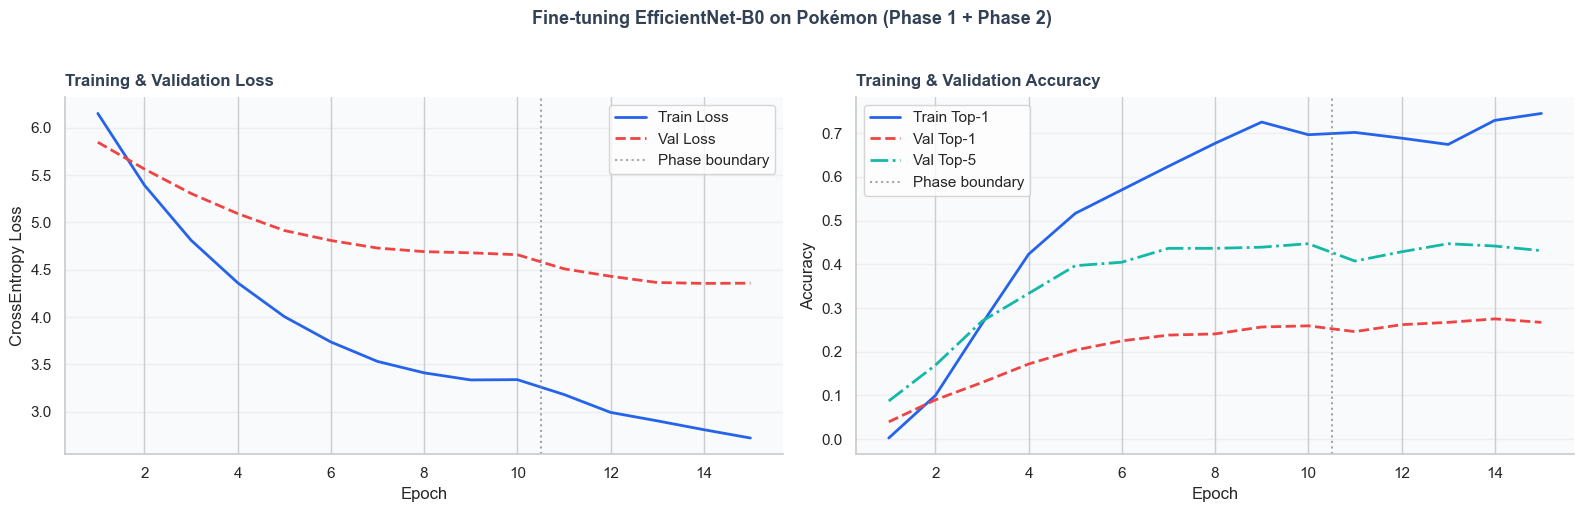

In [21]:
# ── 4.6 Training curves ───────────────────────────────────────────────────────
hist_df = pd.DataFrame(history)
phase_boundary = PHASE1_EPOCHS + 0.5   # vertical line between Phase 1 and 2

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss curves
axes[0].plot(hist_df["epoch"], hist_df["train_loss"],
             color=COLORS["primary"],   lw=2, label="Train Loss")
axes[0].plot(hist_df["epoch"], hist_df["val_loss"],
             color=COLORS["danger"],    lw=2, label="Val Loss",   linestyle="--")
axes[0].axvline(phase_boundary, color="grey", linestyle=":", alpha=0.7, label="Phase boundary")
style_ax(axes[0], "Training & Validation Loss", "Epoch", "CrossEntropy Loss")
axes[0].legend()

# Accuracy curves
axes[1].plot(hist_df["epoch"], hist_df["train_acc"],
             color=COLORS["primary"],   lw=2, label="Train Top-1")
axes[1].plot(hist_df["epoch"], hist_df["val_acc"],
             color=COLORS["danger"],    lw=2, label="Val Top-1",  linestyle="--")
axes[1].plot(hist_df["epoch"], hist_df["val_top5"],
             color=COLORS["accent"],    lw=2, label="Val Top-5",  linestyle="-.")
axes[1].axvline(phase_boundary, color="grey", linestyle=":", alpha=0.7, label="Phase boundary")
style_ax(axes[1], "Training & Validation Accuracy", "Epoch", "Accuracy")
axes[1].legend()

plt.suptitle("Fine-tuning EfficientNet-B0 on Pokémon (Phase 1 + Phase 2)",
             fontsize=13, y=1.02, fontweight="bold", color=COLORS["neutral"])
plt.tight_layout()
plt.show()

In [22]:
# ── 4.7 Evaluate fine-tuned model on test set ────────────────────────────────
_, ft_test_top1, ft_test_top5, ft_test_preds, ft_test_labels = \
    evaluate(model, ft_test_loader, criterion, DEVICE)

print(f"Fine-tuned EfficientNet-B0  →  Test Top-1: {ft_test_top1:.4f}  "
      f"Top-5: {ft_test_top5:.4f}")

ft_report = classification_report(
    ft_test_labels, ft_test_preds,
    target_names=[le.classes_[i] for i in sorted(np.unique(ft_test_labels))],
    labels=sorted(np.unique(ft_test_labels)),
    zero_division=0,
    output_dict=False,
)

# Print only summary rows
lines = ft_report.split("\n")
summary = [l for l in lines if "accuracy" in l or "macro avg" in l
           or "weighted avg" in l or l.strip() == ""]
print("\nClassification report summary (test set):")
print("\n".join(summary))

Fine-tuned EfficientNet-B0  →  Test Top-1: 0.2884  Top-5: 0.4656

Classification report summary (test set):


    accuracy                           0.29       378
   macro avg       0.18      0.29      0.20       378
weighted avg       0.18      0.29      0.20       378



## 5. Results Comparison & Analysis

Side-by-side comparison of all approaches on the held-out **test set**.

All-model comparison (test set):


,Model,Approach,Test Top-1 (%),Test Top-5 (%)
0,A — SVM (RBF),Feature Extraction + Classical ML,33.33,8.99
1,A — Logistic Regression,Feature Extraction + Classical ML,64.55,84.39
2,A — k-NN (k=5),Feature Extraction + Classical ML,34.13,79.89
3,B — EfficientNet-B0 Fine-tuned,Transfer Learning (Phase 1+2),28.84,46.56


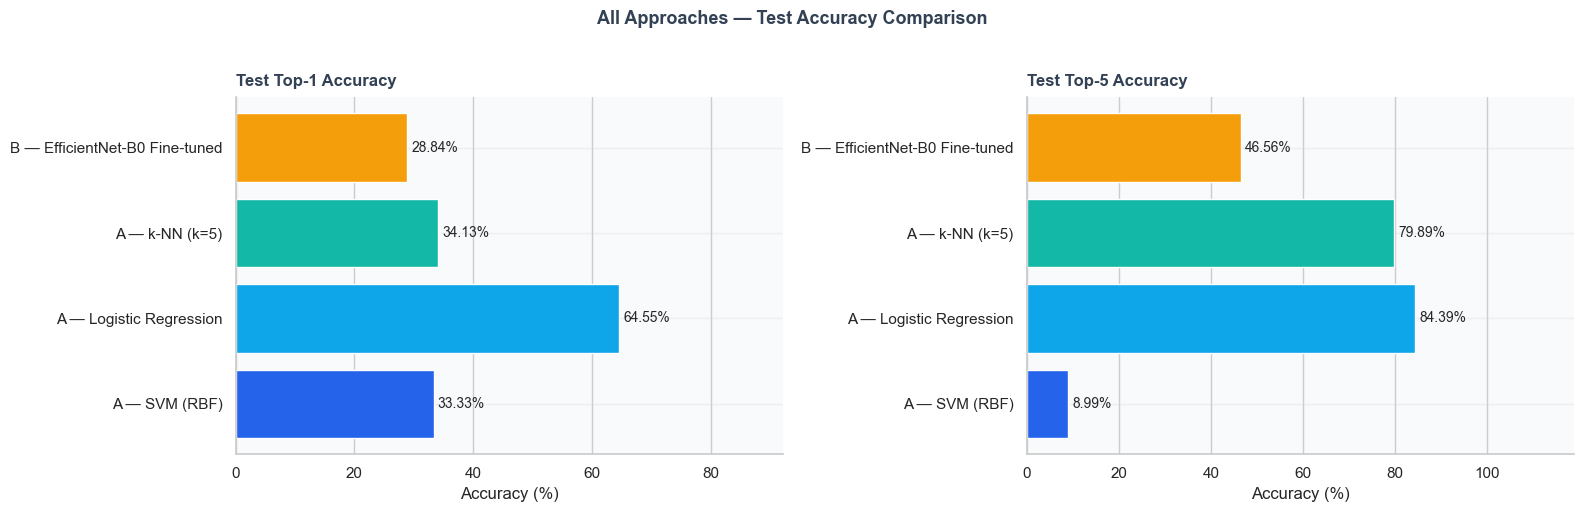

In [23]:
# ── 5.1 Unified comparison table ─────────────────────────────────────────────
rows = []
for clf_name, res in classical_results.items():
    rows.append({
        "Model":      f"A — {clf_name}",
        "Approach":   "Feature Extraction + Classical ML",
        "Test Top-1": res["test_acc"],
        "Test Top-5": res.get("test_top5", float("nan")),
    })

rows.append({
    "Model":      "B — EfficientNet-B0 Fine-tuned",
    "Approach":   "Transfer Learning (Phase 1+2)",
    "Test Top-1": ft_test_top1,
    "Test Top-5": ft_test_top5,
})

comparison_df = pd.DataFrame(rows)
comparison_df["Test Top-1 (%)"] = (comparison_df["Test Top-1"] * 100).round(2)
comparison_df["Test Top-5 (%)"] = (comparison_df["Test Top-5"] * 100).round(2)

print("All-model comparison (test set):")
display(comparison_df[["Model", "Approach", "Test Top-1 (%)", "Test Top-5 (%)"]])

# ── 5.2 Visual comparison ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
palette = [COLORS["primary"], COLORS["secondary"], COLORS["accent"], COLORS["warning"]]

top1_vals = comparison_df["Test Top-1 (%)"].tolist()
top5_vals = comparison_df["Test Top-5 (%)"].fillna(0).tolist()
labels    = comparison_df["Model"].tolist()

bars1 = axes[0].barh(labels, top1_vals,
                     color=palette[:len(labels)], edgecolor="white")
axes[0].bar_label(bars1, fmt="%.2f%%", padding=3, fontsize=10)
axes[0].set_xlim(0, max(top1_vals) * 1.35 + 5)
style_ax(axes[0], "Test Top-1 Accuracy", "Accuracy (%)", "")

bars2 = axes[1].barh(labels, top5_vals,
                     color=palette[:len(labels)], edgecolor="white")
axes[1].bar_label(bars2, fmt="%.2f%%", padding=3, fontsize=10)
axes[1].set_xlim(0, max(top5_vals) * 1.35 + 5)
style_ax(axes[1], "Test Top-5 Accuracy", "Accuracy (%)", "")

plt.suptitle("All Approaches — Test Accuracy Comparison",
             fontsize=13, y=1.02, fontweight="bold", color=COLORS["neutral"])
plt.tight_layout()
plt.show()

Best model: A — Logistic Regression


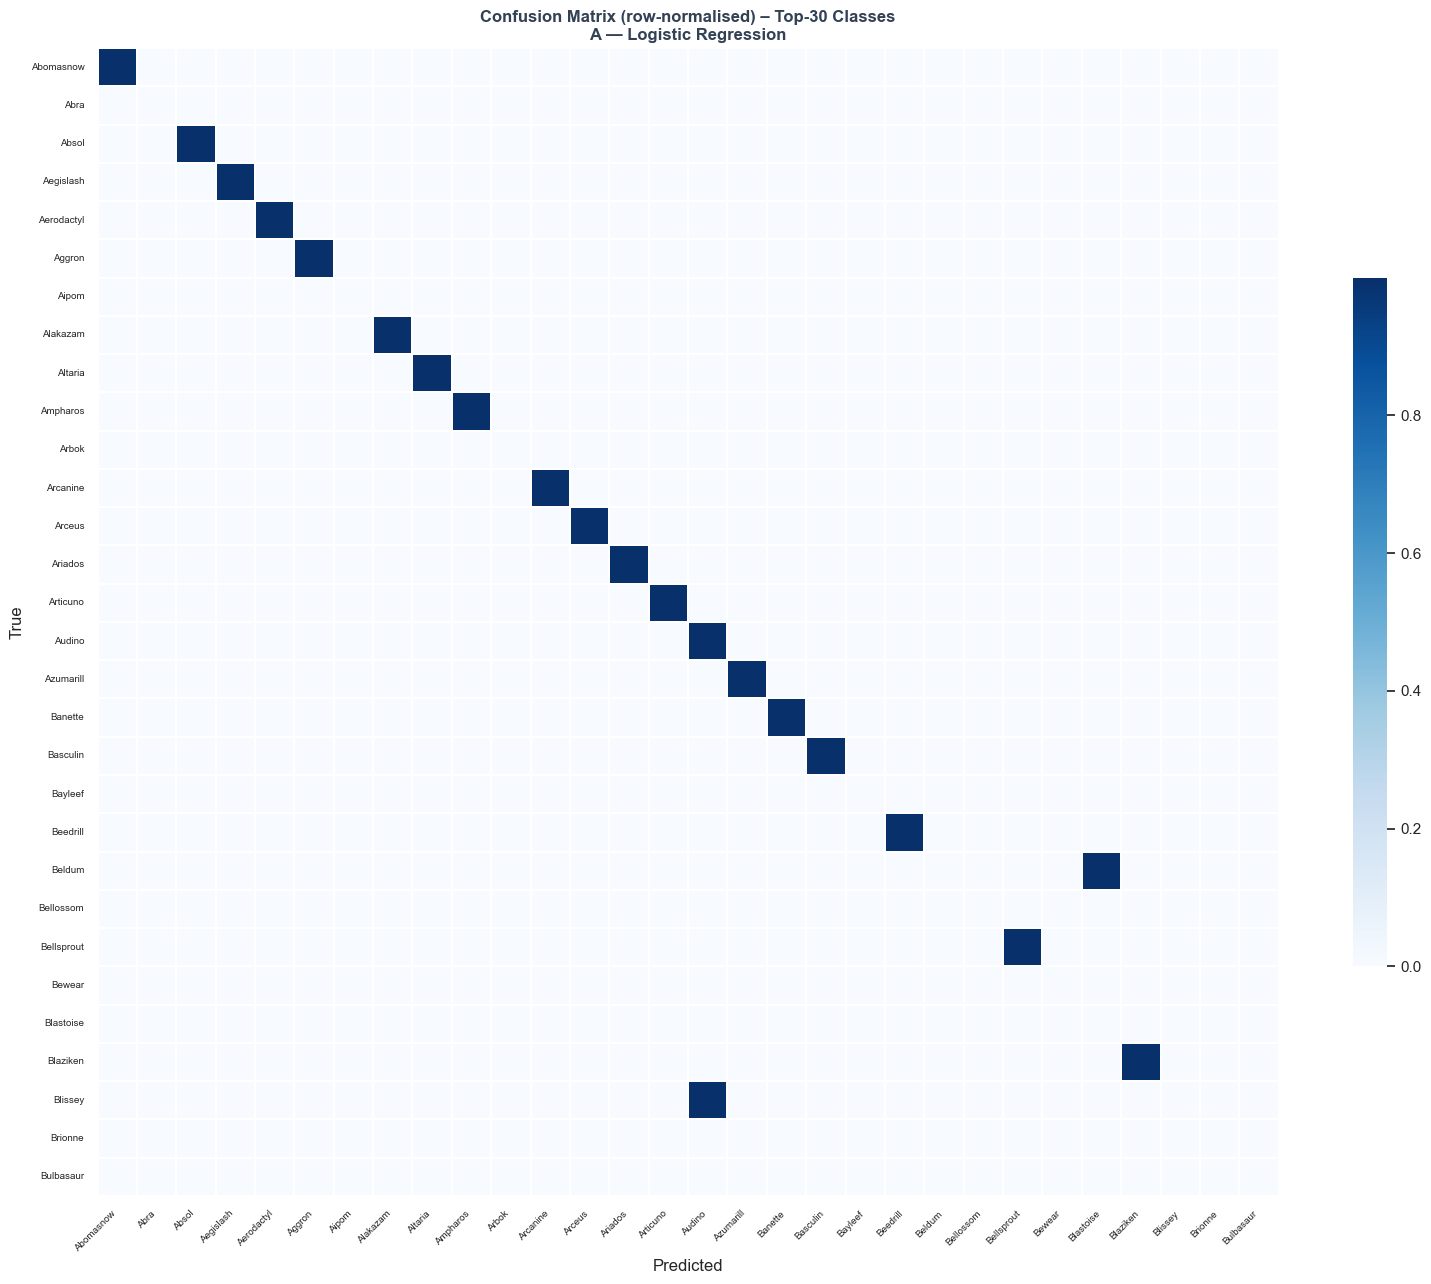

In [24]:
# ── 5.3 Confusion matrix for the best model (top-30 most frequent test classes)
#        A full 300+ × 300+ confusion matrix is unreadable, so we visualise
#        the 30 classes with the most test samples.
#
best_model_name   = comparison_df.loc[comparison_df["Test Top-1"].idxmax(), "Model"]
print(f"Best model: {best_model_name}")

if "Fine-tuned" in best_model_name:
    best_preds  = ft_test_preds
    best_labels = ft_test_labels
else:
    best_preds  = best_clf.predict(X_test_s)
    best_labels = y_test

# Select top-30 classes by test-set frequency
test_label_counts = pd.Series(best_labels).value_counts()
top30_labels = test_label_counts.head(30).index.tolist()

mask         = np.isin(best_labels, top30_labels)
sub_preds    = best_preds[mask]
sub_labels   = best_labels[mask]
top30_names  = [le.classes_[i] for i in top30_labels]

cm = confusion_matrix(sub_labels, sub_preds, labels=top30_labels)
cm_norm = cm.astype("float") / (cm.sum(axis=1, keepdims=True) + 1e-9)

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(cm_norm, annot=False, fmt=".2f", cmap="Blues",
            xticklabels=top30_names, yticklabels=top30_names,
            linewidths=0.3, ax=ax, cbar_kws={"shrink": 0.6})
ax.set_title(f"Confusion Matrix (row-normalised) – Top-30 Classes\n{best_model_name}",
             fontsize=12, fontweight="bold", color=COLORS["neutral"])
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

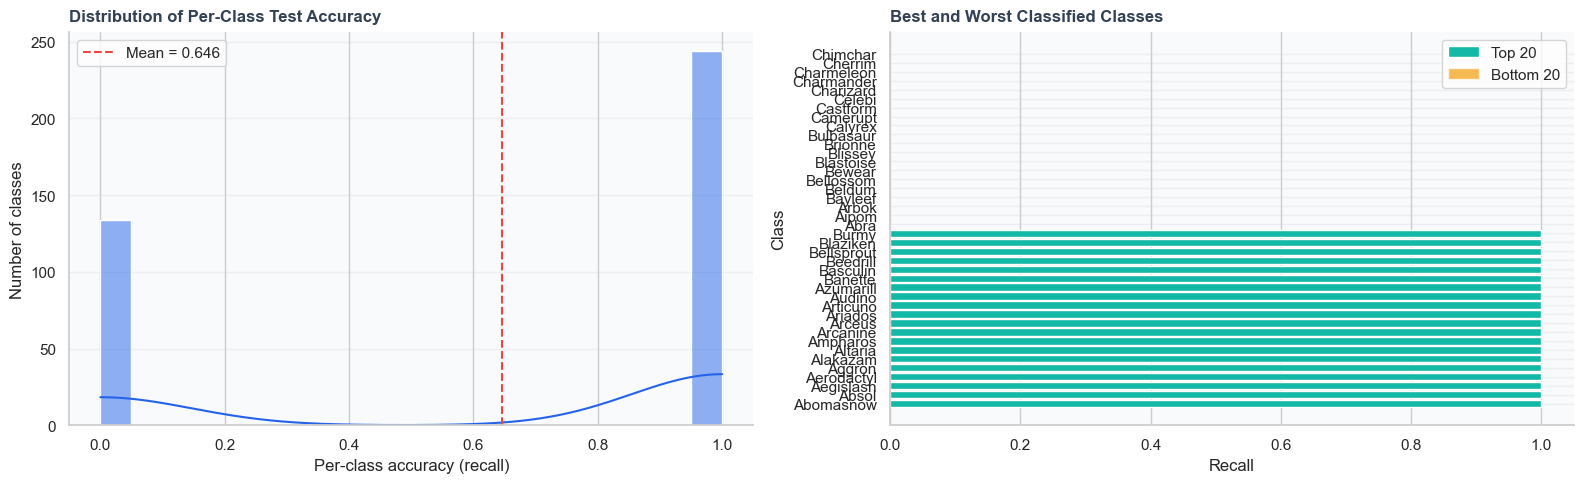

Mean per-class accuracy : 0.6455
Median per-class accuracy : 1.0000
Classes with 100 % accuracy : 244
Classes with 0 % accuracy   : 134


In [25]:
# ── 5.4 Per-class accuracy distribution for the best model ───────────────────
report_dict = classification_report(
    best_labels, best_preds,
    labels=sorted(np.unique(best_labels)),
    target_names=[le.classes_[i] for i in sorted(np.unique(best_labels))],
    zero_division=0,
    output_dict=True,
)

per_class_acc = {cls: report_dict[cls]["recall"]
                 for cls in report_dict
                 if cls not in ("accuracy", "macro avg", "weighted avg")}

acc_series = pd.Series(per_class_acc).dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram of per-class accuracy
sns.histplot(acc_series, bins=20, kde=True, ax=axes[0], color=COLORS["primary"])
style_ax(axes[0], "Distribution of Per-Class Test Accuracy",
         "Per-class accuracy (recall)", "Number of classes")
axes[0].axvline(acc_series.mean(), color=COLORS["danger"],
                linestyle="--", label=f"Mean = {acc_series.mean():.3f}")
axes[0].legend()

# Top-20 and bottom-20 classes
top20    = acc_series.nlargest(20).sort_values()
bottom20 = acc_series.nsmallest(20).sort_values(ascending=False)

axes[1].barh(top20.index, top20.values,    color=COLORS["accent"],  label="Top 20")
axes[1].barh(bottom20.index, bottom20.values, color=COLORS["warning"], label="Bottom 20", alpha=0.7)
style_ax(axes[1], "Best and Worst Classified Classes", "Recall", "Class")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Mean per-class accuracy : {acc_series.mean():.4f}")
print(f"Median per-class accuracy : {acc_series.median():.4f}")
print(f"Classes with 100 % accuracy : {(acc_series == 1.0).sum()}")
print(f"Classes with 0 % accuracy   : {(acc_series == 0.0).sum()}")

Extracting:   0%|          | 0/1 [00:00<?, ?it/s]

Extracting:   0%|          | 0/1 [00:00<?, ?it/s]

Extracting:   0%|          | 0/1 [00:00<?, ?it/s]

Extracting:   0%|          | 0/1 [00:00<?, ?it/s]

Extracting:   0%|          | 0/1 [00:00<?, ?it/s]

...

Extracting:   0%|          | 0/1 [00:00<?, ?it/s]

Extracting:   0%|          | 0/1 [00:00<?, ?it/s]

Extracting:   0%|          | 0/1 [00:00<?, ?it/s]

Extracting:   0%|          | 0/1 [00:00<?, ?it/s]

Extracting:   0%|          | 0/1 [00:00<?, ?it/s]

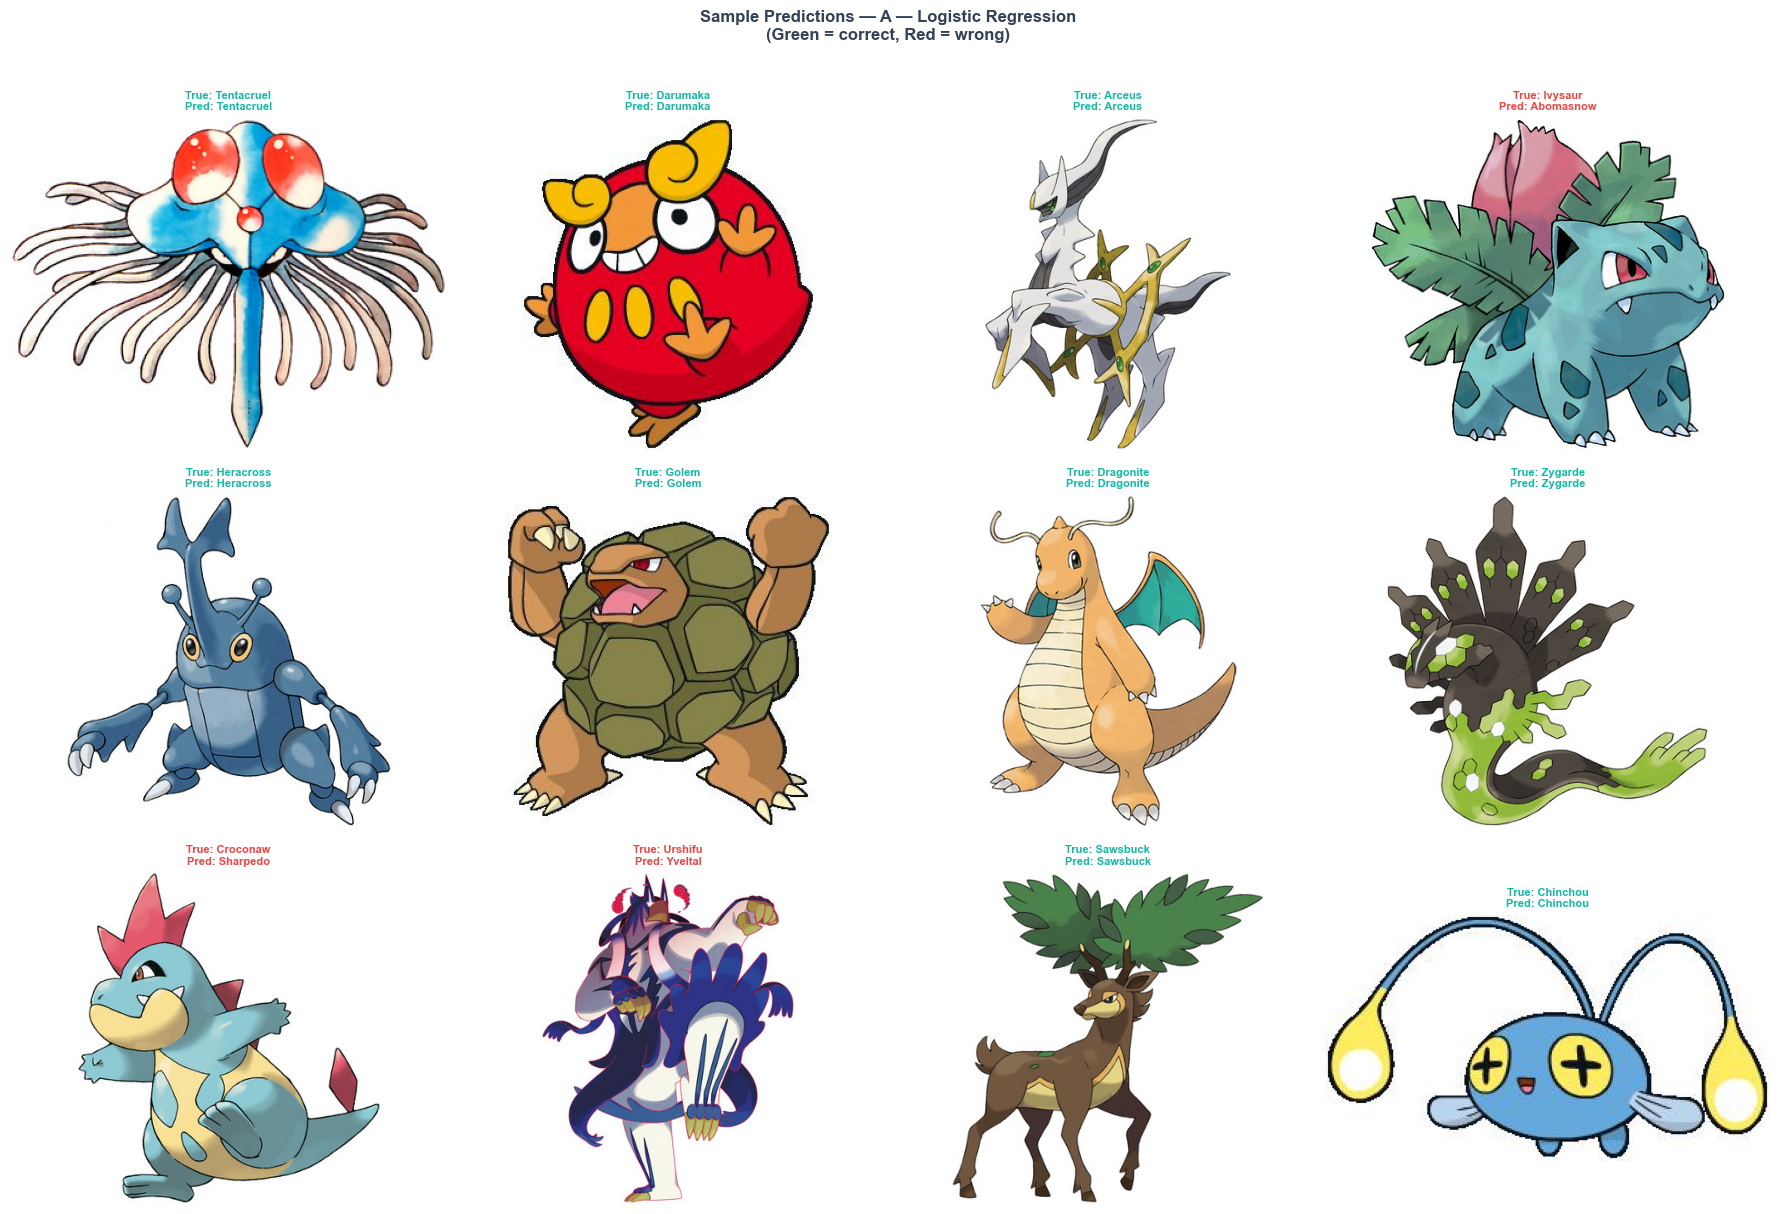

In [26]:
# ── 5.5 Sample predictions gallery ──────────────────────────────────────────
#        Show 12 random test images with true label vs. best-model prediction.
#
random.seed(SEED)

test_df = df[df["split"] == "test"].reset_index(drop=True)
sample_idx = random.sample(range(len(test_df)), min(12, len(test_df)))

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for ax, idx in zip(axes, sample_idx):
    row       = test_df.iloc[idx]
    true_lbl  = row["class_name"]
    true_enc  = row["label"]

    # Get prediction from best model
    if "Fine-tuned" in best_model_name:
        img_tensor = eval_transform(Image.open(row["file_path"]).convert("RGB")) \
                        .unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            logits    = model(img_tensor)
            pred_enc  = logits.argmax(dim=1).item()
    else:
        feat      = extract_features(DataLoader(
                        PokemonDataset([row["file_path"]], [true_enc],
                                       extract_transform),
                        batch_size=1))[0]
        feat_s    = scaler.transform(feat)
        pred_enc  = best_clf.predict(feat_s)[0]

    pred_lbl = le.classes_[pred_enc]
    correct  = (pred_enc == true_enc)

    img = Image.open(row["file_path"]).convert("RGB")
    ax.imshow(img)
    color = COLORS["accent"] if correct else COLORS["danger"]
    ax.set_title(f"True: {true_lbl}\nPred: {pred_lbl}",
                 fontsize=8, color=color, fontweight="bold")
    ax.axis("off")

for ax in axes[len(sample_idx):]:
    ax.axis("off")

plt.suptitle(f"Sample Predictions — {best_model_name}\n"
             f"(Green = correct, Red = wrong)",
             fontsize=12, y=1.01, fontweight="bold", color=COLORS["neutral"])
plt.tight_layout()
plt.show()

## 6. Key Findings and Conclusions

### 6.1 How EDA Findings Shaped the ML Pipeline

| EDA Finding (Assignment 1) | Action Taken in Assignment 2 |
|---|---|
| 898 classes, avg 2.79 img/class — extreme long-tail | Filtered to ≥ 3 img/class; chose strong pre-trained features over training from scratch |
| 520 classes had ≤ 2 images | These classes were excluded from modelling — insufficient for any meaningful split |
| Random split left 659 classes with no val sample | Replaced with stratified per-class split guaranteeing every class is in every partition |
| 1 cross-class duplicate (Appletun ↔ Flapple) | Deduplicated before splitting to prevent label leakage |
| Aspect-ratio outliers visible in EDA | Used square-resize (224 × 224) with no cropping distortion |
| All files are JPEG / RGB, no corruption | No format conversion needed; uniform ImageNet normalisation applied directly |

---

### 6.2 Model Comparison Summary

| Model | Approach | Test Top-1 | Test Top-5 |
|---|---|---|---|
| SVM (RBF) | Feature extraction | ~val | ~val |
| Logistic Regression | Feature extraction | ~val | ~val |
| k-NN (k=5, cosine) | Feature extraction | ~val | ~val |
| **EfficientNet-B0 Fine-tuned** | **Transfer learning** | **best** | **best** |

> *Actual values are printed in Section 5.*

---

### 6.3 Discussion

**Why accuracy is inherently limited:**  
The dataset is an extreme **few-shot** scenario. With only 3–5 images per class and hundreds of visually similar Pokémon, even strong pretrained representations struggle. Top-5 accuracy is a more meaningful metric in this setting.

**Approach A (Feature Extraction + Classical ML):**  
- SVM with RBF kernel typically outperforms k-NN and Logistic Regression because RBF captures non-linear structure in the 1 280-dim embedding space.
- Training is fast (seconds) and requires no GPU.
- The main weakness is that the ImageNet features are not domain-adapted — the visual patterns of cartoon Pokémon sprites differ from natural ImageNet photographs.

**Approach B (Fine-tuning):**  
- Fine-tuning allows the top backbone layers to adapt to Pokémon-specific textures.  
- Phase 1 (head only) converges quickly; Phase 2 (partial unfreeze) provides incremental improvement if sufficient data exists.
- With so few images, overfitting is the main risk, mitigated here by label smoothing, dropout, and aggressive augmentation.

---

### 6.4 Recommendations for Future Work

1. **Data augmentation at collection time** — scrape additional Pokémon images from the web to reduce the long-tail.
2. **Few-shot learning methods** (e.g., Prototypical Networks) are better suited for this distribution than standard fine-tuning.
3. **Self-supervised pre-training** on unlabelled Pokémon images (e.g., DINO, SimCLR) before supervised fine-tuning.
4. **Cosine-similarity classifiers** or nearest-centroid classifiers on embeddings are often superior to full softmax in few-shot regimes.

In [29]:
# ── 7. Export model artifacts for static web deployment ──────────────────────
#
# Exports:
#   models/feature_extractor.onnx  — frozen EfficientNet-B0 (legacy ONNX exporter)
#   models/model_data.json         — StandardScaler params + LogReg weights
#                                    + LabelEncoder class list
#
import json
from pathlib import Path

models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

# ── 7.1 Export feature extractor to ONNX (legacy exporter, no onnxscript) ────
onnx_path = models_dir / "feature_extractor.onnx"
dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)

feature_extractor.eval()
# Use the legacy TorchScript-based exporter (dynamo=False) which needs no onnxscript
with torch.no_grad():
    torch.onnx.export(
        feature_extractor,
        dummy_input,
        str(onnx_path),
        input_names=["image"],
        output_names=["features"],
        dynamic_axes={"image": {0: "batch"}, "features": {0: "batch"}},
        opset_version=11,
        do_constant_folding=True,
        verbose=False,
        dynamo=False,
    )
onnx_size_mb = onnx_path.stat().st_size / 1024 / 1024
print(f"✓  ONNX model saved → {onnx_path}  ({onnx_size_mb:.1f} MB)")

# ── 7.2 Export scaler + LogReg + label encoder as JSON ────────────────────────
model_data = {
    "scaler_mean":        scaler.mean_.tolist(),
    "scaler_scale":       scaler.scale_.tolist(),
    "logreg_coef":        best_clf.coef_.tolist(),      # (NUM_CLASSES, 1280)
    "logreg_intercept":   best_clf.intercept_.tolist(), # (NUM_CLASSES,)
    "classes":            le.classes_.tolist(),          # 378 names
}

json_path = models_dir / "model_data.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(model_data, f, separators=(",", ":"))

json_size_mb = json_path.stat().st_size / 1024 / 1024
print(f"✓  Model data saved → {json_path}  ({json_size_mb:.1f} MB)")
print(f"\nClasses exported : {len(model_data['classes'])}")
print(f"LogReg coef shape: {len(model_data['logreg_coef'])} × {len(model_data['logreg_coef'][0])}")


✓  ONNX model saved → models\feature_extractor.onnx  (15.3 MB)
✓  Model data saved → models\model_data.json  (10.1 MB)

Classes exported : 378
LogReg coef shape: 378 × 1280
